## Problem 3b. Numerical evaluation of integrals via Monte Carlo simulation

The task is to estimate the integral $$\int_{a}^{b}f(u) \,du$$ Geometrically this is the area under the curve $y = f(u)$ from [0, 1]. Since, $f(u)$ is bounded from [0, 1], this can all be represented within a [0, 1]^2 unit square. First lets define a function to represent $f(u)$.  

In [3]:
def f(u):
    return (u ** 4) / ((u ** 6) + 1)

Now it is important to define what U and V represent here. We will let U be a random point along the horizontal axis, and V be a random point along the vertical axis. U ~ Uniform(0,1), and V ~ Uniform(0, 1). It follows that the random point (U, V) is a random point on the unit square [0, 1]^2. Then the indicator 1{V≤f(U)}, just represents a 1 if for a given point, it's height V is under the curve modeled by f(u). By then taking the expectation of this, we can deduce the Probability a random point is below the curve. Monte Carlos simply replaces the expectation with an average.  

In [9]:
import numpy as np

def area_estimate_mc(N: int, rng: np.random.Generator) -> float:
    # randomly get our U and V values. 
    
    U = rng.random(N)
    V = rng.random(N)
    
    return float(np.mean(V <= f(U)))

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from math import floor
from scipy.integrate import quad
    
def main(seed: int = 0):
    rng = np.random.default_rng(seed)

    # N = floor(10^x), x = 1, 1.1, ..., 5
    xs = np.arange(1.0, 5.0 + 1e-9, 0.1)
    Ns = np.array([floor(10**x) for x in xs], dtype=int)

    # Monte Carlo estimates E(N) using the above function area_estima_mc    
    estimates = np.array([area_estimate_mc(N, rng) for N in Ns], dtype = float)

    # The reference value was computed using SciPy’s quad adaptive quadrature routine
    true_val, true_err = quad(lambda u: (u**4) / (1.0 + u**6), 0.0, 1.0)

    # Plot
    plt.figure()
    plt.plot(Ns, estimates, marker="o", linestyle="-", markersize=3)
    plt.axhline(true_val, linestyle="--")
    plt.xscale("log")
    plt.xlabel("N (log scale)")
    plt.ylabel("E(N) Monte Carlo estimate")
    plt.title("Monte Carlo estimate of integral vs N")
    plt.tight_layout()

    # Save figure for write-up / Git
    plt.savefig("mc_integral_plot.png", dpi=200)

    # Printing the numerics and values for reference
    print(f"Reference (quad) value: {true_val:.10f} (estimated abs error {true_err:.2e})")
    print("N\tE(N)")
    for N, est in zip(Ns[::5], estimates[::5]):  # print every 5th to keep it short
        print(f"{N}\t{est:.6f}")
    


Reference (quad) value: 0.1434257774 (estimated abs error 4.13e-10)
N	E(N)
10	0.100000
31	0.129032
100	0.200000
316	0.148734
1000	0.142000
3162	0.150854
10000	0.151800
31622	0.144899
100000	0.144690


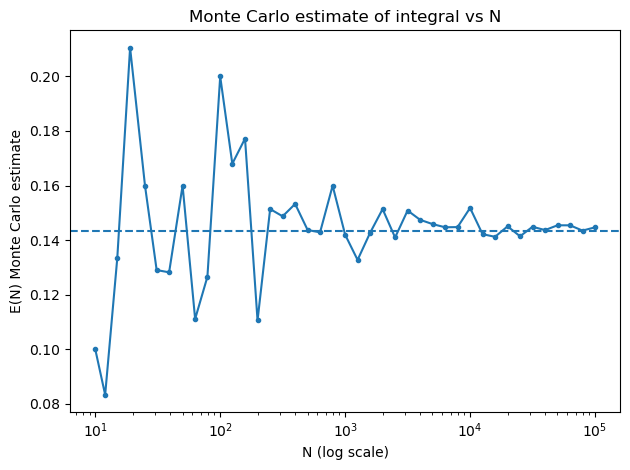

In [23]:
main(1)

To exmaine the plot, the dashed line represents the actual value of the integral. This value was created using the quad adaptive quadrature routine, from the scipy library.  The non dashed line represents our estimate of the integral via Monte Carlo estimation as a function of N, which is in turn a function of x. N = floor(10x) with x = 1, 1.1, 1.2, . . . , 4.9, 5. Our graph clearly demonstrates the Mone Carlo estimate getting closer to the true valuation of the integral as the value of N increases. 